# 03 - Frequentist Hypothesis Testing

**Objective:** Analyze the A/B test results using classical statistical methods.

This notebook covers:
1. Two-proportion z-test
2. Confidence intervals for the effect
3. Chi-squared test (secondary validation)
4. Effect size calculation
5. Interpretation of results

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, confint_proportions_2indep

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

In [2]:
# Load data
df = pd.read_csv('../data/raw/ab_test_data.csv')
df['signup_date'] = pd.to_datetime(df['signup_date'])

print(f"Dataset: {len(df):,} users")

Dataset: 50,000 users


## 1. Prepare the Data

In [3]:
# Separate control and treatment
control = df[df['variant'] == 'control']
treatment = df[df['variant'] == 'treatment']

# Calculate key metrics
n_control = len(control)
n_treatment = len(treatment)

conversions_control = control['activated_7d'].sum()
conversions_treatment = treatment['activated_7d'].sum()

rate_control = conversions_control / n_control
rate_treatment = conversions_treatment / n_treatment

print("Summary Statistics:")
print(f"{'':20} {'Control':>12} {'Treatment':>12}")
print("-" * 46)
print(f"{'Sample Size':20} {n_control:>12,} {n_treatment:>12,}")
print(f"{'Conversions':20} {conversions_control:>12,} {conversions_treatment:>12,}")
print(f"{'Conversion Rate':20} {rate_control:>12.4f} {rate_treatment:>12.4f}")

Summary Statistics:
                          Control    Treatment
----------------------------------------------
Sample Size                24,965       25,035
Conversions                 7,828        9,430
Conversion Rate            0.3136       0.3767


## 2. Two-Proportion Z-Test

The z-test for two proportions tests whether the difference between two proportions is statistically significant.

**Hypotheses:**
- $H_0$: $p_{treatment} = p_{control}$ (no difference)
- $H_1$: $p_{treatment} > p_{control}$ (treatment is better)

**Test Statistic:**
$$z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})(\frac{1}{n_1} + \frac{1}{n_2})}}$$

where $\hat{p}$ is the pooled proportion.

In [4]:
def two_proportion_ztest(successes, samples, alternative='larger'):
    """
    Perform a two-proportion z-test.
    
    Parameters
    ----------
    successes : array-like
        Number of successes in each group [control, treatment]
    samples : array-like
        Sample size in each group [control, treatment]
    alternative : str
        'two-sided', 'larger', or 'smaller'
        
    Returns
    -------
    dict with z-statistic, p-value, and interpretation
    """
    # Conversion rates
    p1 = successes[0] / samples[0]  # control
    p2 = successes[1] / samples[1]  # treatment
    
    # Pooled proportion (under null hypothesis)
    p_pooled = (successes[0] + successes[1]) / (samples[0] + samples[1])
    
    # Standard error
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/samples[0] + 1/samples[1]))
    
    # Z-statistic
    z_stat = (p2 - p1) / se
    
    # P-value
    if alternative == 'larger':
        p_value = 1 - stats.norm.cdf(z_stat)
    elif alternative == 'smaller':
        p_value = stats.norm.cdf(z_stat)
    else:  # two-sided
        p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    
    return {
        'z_statistic': z_stat,
        'p_value': p_value,
        'control_rate': p1,
        'treatment_rate': p2,
        'pooled_rate': p_pooled,
        'standard_error': se
    }

# Run the test
successes = [conversions_control, conversions_treatment]
samples = [n_control, n_treatment]

result = two_proportion_ztest(successes, samples, alternative='larger')

print("\n" + "="*60)
print("TWO-PROPORTION Z-TEST RESULTS")
print("="*60)
print(f"\nTest: H₁: p_treatment > p_control (one-sided)")
print(f"\nZ-statistic: {result['z_statistic']:.4f}")
print(f"P-value: {result['p_value']:.6f}")
print(f"\nSignificance level: α = 0.05")

if result['p_value'] < 0.05:
    print(f"\n✓ REJECT H₀: The treatment effect is statistically significant (p < 0.05)")
else:
    print(f"\n✗ FAIL TO REJECT H₀: No significant difference detected (p ≥ 0.05)")


TWO-PROPORTION Z-TEST RESULTS

Test: H₁: p_treatment > p_control (one-sided)

Z-statistic: 14.8423
P-value: 0.000000

Significance level: α = 0.05

✓ REJECT H₀: The treatment effect is statistically significant (p < 0.05)


## 3. Confidence Interval for the Difference

A confidence interval tells us the range of plausible values for the true treatment effect.

In [5]:
def confidence_interval_diff(successes, samples, confidence=0.95):
    """
    Calculate confidence interval for difference in proportions.
    Uses the Wald method.
    """
    p1 = successes[0] / samples[0]  # control
    p2 = successes[1] / samples[1]  # treatment
    
    # Point estimate
    diff = p2 - p1
    
    # Standard error for difference (not pooled)
    se = np.sqrt(p1*(1-p1)/samples[0] + p2*(1-p2)/samples[1])
    
    # Z critical value
    z_crit = stats.norm.ppf(1 - (1-confidence)/2)
    
    # Confidence interval
    ci_lower = diff - z_crit * se
    ci_upper = diff + z_crit * se
    
    return {
        'point_estimate': diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'standard_error': se,
        'confidence_level': confidence
    }

ci_result = confidence_interval_diff(successes, samples, confidence=0.95)

print("\n" + "="*60)
print("CONFIDENCE INTERVAL FOR TREATMENT EFFECT")
print("="*60)
print(f"\nPoint Estimate (Treatment - Control): {ci_result['point_estimate']:.4f}")
print(f"  = {ci_result['point_estimate']*100:.2f} percentage points")
print(f"\n95% Confidence Interval: [{ci_result['ci_lower']:.4f}, {ci_result['ci_upper']:.4f}]")
print(f"  = [{ci_result['ci_lower']*100:.2f}pp, {ci_result['ci_upper']*100:.2f}pp]")

# Relative lift
relative_lift = ci_result['point_estimate'] / rate_control
print(f"\nRelative Lift: {relative_lift:.2%}")


CONFIDENCE INTERVAL FOR TREATMENT EFFECT

Point Estimate (Treatment - Control): 0.0631
  = 6.31 percentage points

95% Confidence Interval: [0.0548, 0.0714]
  = [5.48pp, 7.14pp]

Relative Lift: 20.13%


C:\Users\deven\AppData\Local\Temp\ipykernel_11300\2739747531.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


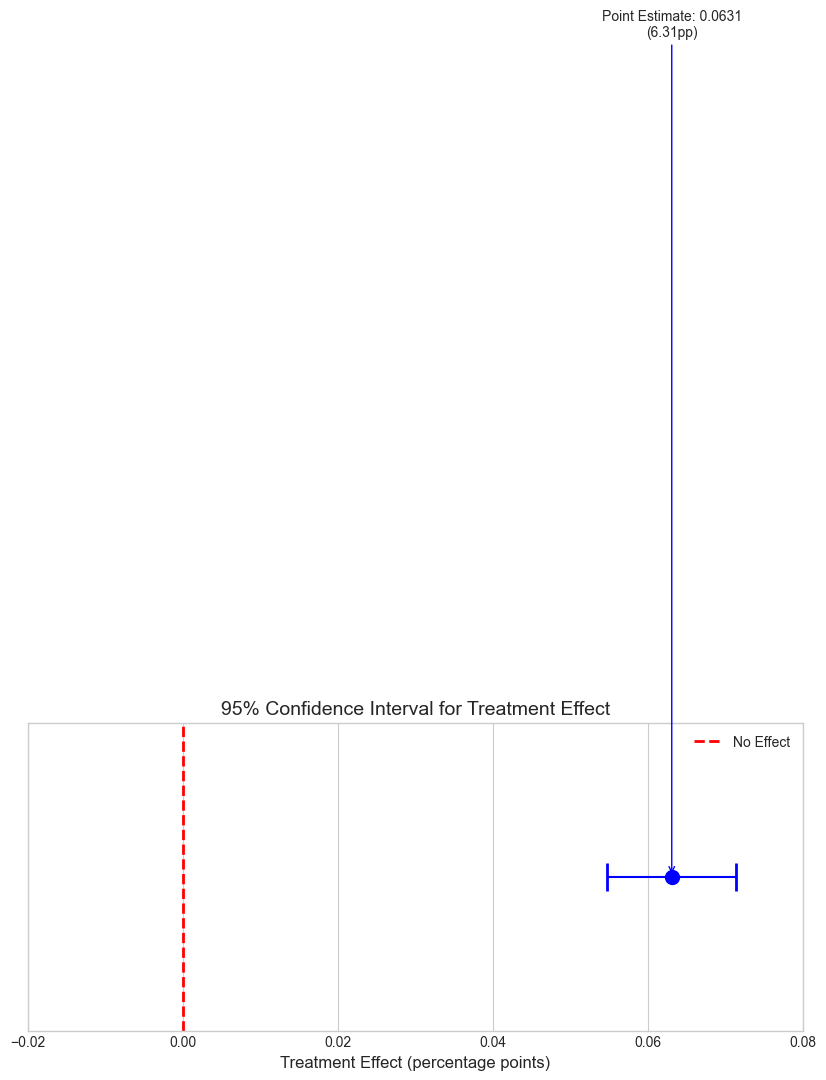


✓ The entire CI is above 0, suggesting a real positive effect.


In [6]:
# Visualize the confidence interval
fig, ax = plt.subplots(figsize=(10, 4))

# Plot CI
ax.errorbar(ci_result['point_estimate'], 0, 
            xerr=[[ci_result['point_estimate'] - ci_result['ci_lower']], 
                  [ci_result['ci_upper'] - ci_result['point_estimate']]],
            fmt='o', capsize=10, capthick=2, markersize=10, color='blue')

# Add vertical line at 0 (no effect)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Effect')

# Formatting
ax.set_xlabel('Treatment Effect (percentage points)', fontsize=12)
ax.set_title('95% Confidence Interval for Treatment Effect', fontsize=14)
ax.set_yticks([])
ax.set_xlim(-0.02, 0.08)

# Add annotations
ax.annotate(f'Point Estimate: {ci_result["point_estimate"]:.4f}\n({ci_result["point_estimate"]*100:.2f}pp)',
            xy=(ci_result['point_estimate'], 0),
            xytext=(ci_result['point_estimate'], 0.3),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='blue'))

ax.legend()
plt.tight_layout()
plt.show()

# Interpretation
if ci_result['ci_lower'] > 0:
    print("\n✓ The entire CI is above 0, suggesting a real positive effect.")
elif ci_result['ci_upper'] < 0:
    print("\n✗ The entire CI is below 0, suggesting a real negative effect.")
else:
    print("\n⚠️ The CI includes 0, so we cannot rule out no effect.")

## 4. Chi-Squared Test (Secondary Validation)

The chi-squared test is another way to test for association between variant and conversion.

In [7]:
# Create contingency table
contingency_table = pd.crosstab(df['variant'], df['activated_7d'], margins=True)
print("Contingency Table:")
print(contingency_table)

# Chi-squared test
contingency = pd.crosstab(df['variant'], df['activated_7d'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-squared statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

# This should match the z-test (chi2 = z^2 for 2x2 table)
print(f"\nVerification: √χ² = {np.sqrt(chi2):.4f} (should ≈ |z| = {abs(result['z_statistic']):.4f})")

Contingency Table:
activated_7d  False   True    All
variant                          
control       17137   7828  24965
treatment     15605   9430  25035
All           32742  17258  50000

Chi-squared statistic: 220.0137
Degrees of freedom: 1
P-value: 0.000000

Verification: √χ² = 14.8329 (should ≈ |z| = 14.8423)


## 5. Effect Size (Cohen's h)

Effect size tells us how *practically significant* the result is, independent of sample size.

Cohen's h for proportions:
$$h = 2 \arcsin(\sqrt{p_1}) - 2 \arcsin(\sqrt{p_2})$$

Interpretation guidelines:
- |h| ≈ 0.2: small effect
- |h| ≈ 0.5: medium effect  
- |h| ≈ 0.8: large effect

In [8]:
def cohens_h(p1, p2):
    """Calculate Cohen's h effect size for two proportions."""
    return 2 * np.arcsin(np.sqrt(p2)) - 2 * np.arcsin(np.sqrt(p1))

h = cohens_h(rate_control, rate_treatment)

print("\n" + "="*60)
print("EFFECT SIZE")
print("="*60)
print(f"\nCohen's h: {h:.4f}")

# Interpretation
if abs(h) < 0.2:
    interpretation = "Small"
elif abs(h) < 0.5:
    interpretation = "Small to Medium"
elif abs(h) < 0.8:
    interpretation = "Medium to Large"
else:
    interpretation = "Large"

print(f"Interpretation: {interpretation} effect")
print("\nReference: |h| ≈ 0.2 (small), 0.5 (medium), 0.8 (large)")


EFFECT SIZE

Cohen's h: 0.1329
Interpretation: Small effect

Reference: |h| ≈ 0.2 (small), 0.5 (medium), 0.8 (large)


## 6. Summary of Frequentist Results

In [11]:
print("\n" + "="*70)
print("FREQUENTIST ANALYSIS SUMMARY")
print("="*70)

print(f"""
PRIMARY METRIC: 7-Day Activation Rate

Conversion Rates                                              
─────────────────                                             
  Control:     {rate_control:.4f} ({rate_control*100:.2f}%)                              
  Treatment:   {rate_treatment:.4f} ({rate_treatment*100:.2f}%)                            
                                                               
  Absolute Lift: {ci_result['point_estimate']:+.4f} ({ci_result['point_estimate']*100:+.2f} percentage points)        
  Relative Lift: {relative_lift:+.2%}                                         

  
Statistical Significance                                       
─────────────────────────                                      
  Z-statistic:  {result['z_statistic']:.4f}                                          
  P-value:      {result['p_value']:.6f}                                        
  95% CI:       [{ci_result['ci_lower']:.4f}, {ci_result['ci_upper']:.4f}]                            
                                                                
  Result: {'SIGNIFICANT (p < 0.05)' if result['p_value'] < 0.05 else 'NOT SIGNIFICANT (p ≥ 0.05)':44}

Effect Size                                                    
───────────                                                    
  Cohen's h: {h:.4f} ({interpretation})                               
""")

# Plain English conclusion
print("\nCONCLUSION (Plain English):")
print("-" * 70)
print(f"The new guided onboarding increased 7-day activation rate by")
print(f"{ci_result['point_estimate']*100:.2f} percentage points (from {rate_control*100:.2f}% to {rate_treatment*100:.2f}%).")
print(f"\nWe are 95% confident the true effect is between {ci_result['ci_lower']*100:.2f}pp and {ci_result['ci_upper']*100:.2f}pp.")
if result['p_value'] < 0.05:
    print(f"\nThis result is statistically significant (p = {result['p_value']:.4f}).")
else:
    print(f"\nThis result is NOT statistically significant (p = {result['p_value']:.4f}).")


FREQUENTIST ANALYSIS SUMMARY

PRIMARY METRIC: 7-Day Activation Rate

Conversion Rates                                              
─────────────────                                             
  Control:     0.3136 (31.36%)                              
  Treatment:   0.3767 (37.67%)                            
                                                               
  Absolute Lift: +0.0631 (+6.31 percentage points)        
  Relative Lift: +20.13%                                         

  
Statistical Significance                                       
─────────────────────────                                      
  Z-statistic:  14.8423                                          
  P-value:      0.000000                                        
  95% CI:       [0.0548, 0.0714]                            
                                                                
  Result: SIGNIFICANT (p < 0.05)                      

Effect Size                                       

## Important Note: What the P-Value Actually Means

**Common Misconception:** "The p-value is the probability that the null hypothesis is true."

**Correct Interpretation:** The p-value is the probability of observing data at least as extreme as what we observed, *assuming the null hypothesis is true*.

In our case:
- P-value = probability of seeing a lift this large (or larger) if there's actually no real effect
- A small p-value means it would be unlikely to see this result by chance alone
- It does NOT tell us the probability that the treatment works

---

## Next Steps

Frequentist analysis shows the result is statistically significant, but let's get a fuller picture:

**→ Notebook 04: Bayesian A/B Testing**

We'll calculate:
- Probability that treatment is better than control
- Expected loss if we make the wrong decision
- Full posterior distributions